<a href="https://colab.research.google.com/github/anadelialo/economy_2026/blob/main/apple_analysis2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Extracción de datos
ticker = 'AAPL'
# Apple salió a bolsa a finales de 1980. Usamos la fecha actual (2026) para tener todo.
print(f"Descargando datos históricos de {ticker}...")
df = yf.download(ticker, start='1980-12-12', end='2026-04-10')

# Limpieza
# Eliminar posibles valores nulos de la descarga
df = df.dropna()

# Crear variables financieras para el modelo predictivo
df['Retorno_Diario'] = df['Close'].pct_change()
df['SMA_20'] = df['Close'].rolling(window=20).mean() # Media móvil corta (1 mes hábil)
df['SMA_50'] = df['Close'].rolling(window=50).mean() # Media móvil media (2.5 meses)
df['Volatilidad_20d'] = df['Retorno_Diario'].rolling(window=20).std()

# Eliminar los primeros 50 días que ahora tienen NaN por el cálculo de la media móvil
df = df.dropna()

print(f"\nLimpieza finalizada. Total de registros útiles: {df.shape[0]} filas.")

# Guardar la base de datos
df.to_csv(f"{ticker}_Database_Cleaned.csv")
print("Base de datos guardada exitosamente.")
df.head()

Descargando datos históricos de AAPL...


[*********************100%***********************]  1 of 1 completed



Limpieza finalizada. Total de registros útiles: 11373 filas.
Base de datos guardada exitosamente.


Price,Close,High,Low,Open,Volume,Retorno_Diario,SMA_20,SMA_50,Volatilidad_20d
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,
Date,,,,,,,,,
1981-02-24,0.081203,0.082057,0.081203,0.082057,16979200,-0.035531,0.093255,0.101537,0.033942
1981-02-25,0.086331,0.086758,0.086331,0.086331,19488000,0.063154,0.092101,0.101298,0.038141
1981-02-26,0.087613,0.088040,0.087613,0.087613,10841600,0.014851,0.091182,0.101187,0.038251
1981-02-27,0.090605,0.091460,0.090605,0.090605,14761600,0.034153,0.090605,0.101272,0.038823
1981-03-02,0.091032,0.091460,0.091032,0.091032,11760000,0.004717,0.090327,0.101324,0.037097


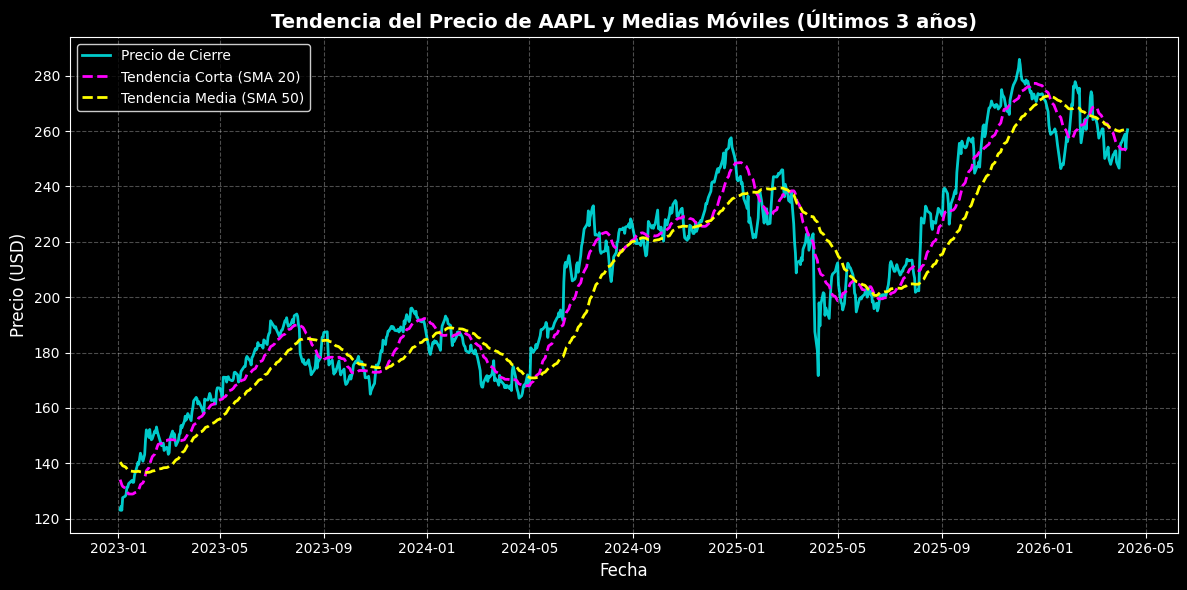

In [2]:
plt.style.use('dark_background')

# --- Gráfica 1: Tendencia Histórica y Medias Móviles ---
# Filtramos los últimos 3 años
df_recent = df.loc['2023-01-01':]

plt.figure(figsize=(12, 6))
plt.plot(df_recent.index, df_recent['Close'], label='Precio de Cierre', color='#00ffff', alpha=0.8, linewidth=2)
plt.plot(df_recent.index, df_recent['SMA_20'], label='Tendencia Corta (SMA 20)', color='#ff00ff', linestyle='--', linewidth=2)
plt.plot(df_recent.index, df_recent['SMA_50'], label='Tendencia Media (SMA 50)', color='#ffff00', linestyle='--', linewidth=2)

plt.title('Tendencia del Precio de AAPL y Medias Móviles (Últimos 3 años)', fontsize=14, fontweight='bold')
plt.ylabel('Precio (USD)', fontsize=12)
plt.xlabel('Fecha', fontsize=12)
plt.legend(loc='upper left', facecolor='black', edgecolor='white')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

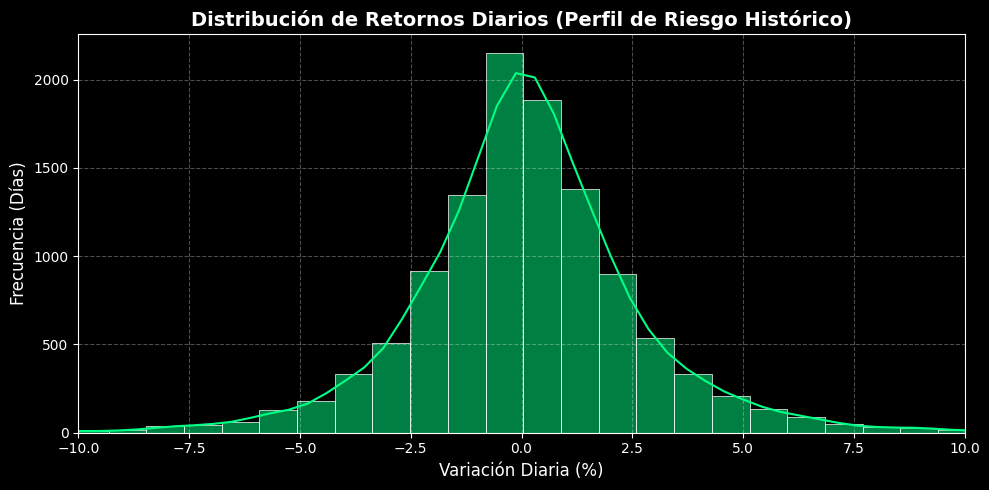

In [3]:
# --- Gráfica 2: Distribución de la Volatilidad ---
plt.figure(figsize=(10, 5))
sns.histplot(df['Retorno_Diario'] * 100, bins=100, kde=True, color='#00ff85')
plt.title('Distribución de Retornos Diarios (Perfil de Riesgo Histórico)', fontsize=14, fontweight='bold')
plt.xlabel('Variación Diaria (%)', fontsize=12)
plt.ylabel('Frecuencia (Días)', fontsize=12)
plt.xlim(-10, 10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

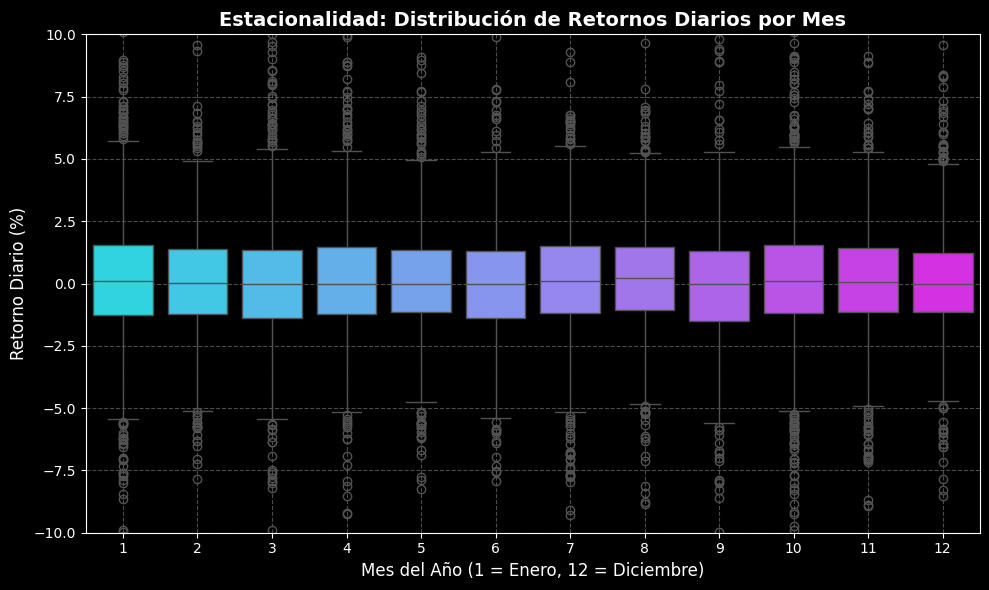

In [4]:
# --- Gráfica 3: Estacionalidad Mensual ---
# Extraemos el mes del índice de fechas
df['Mes'] = df.index.month

plt.figure(figsize=(10, 6))
# Usamos un boxplot para ver la dispersión de los retornos cada mes
sns.boxplot(x='Mes', y=df['Retorno_Diario'] * 100, data=df, palette='cool')
plt.title('Estacionalidad: Distribución de Retornos Diarios por Mes', fontsize=14, fontweight='bold')
plt.xlabel('Mes del Año (1 = Enero, 12 = Diciembre)', fontsize=12)
plt.ylabel('Retorno Diario (%)', fontsize=12)
plt.ylim(-10, 10) # Acotamos para ver mejor la caja central
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

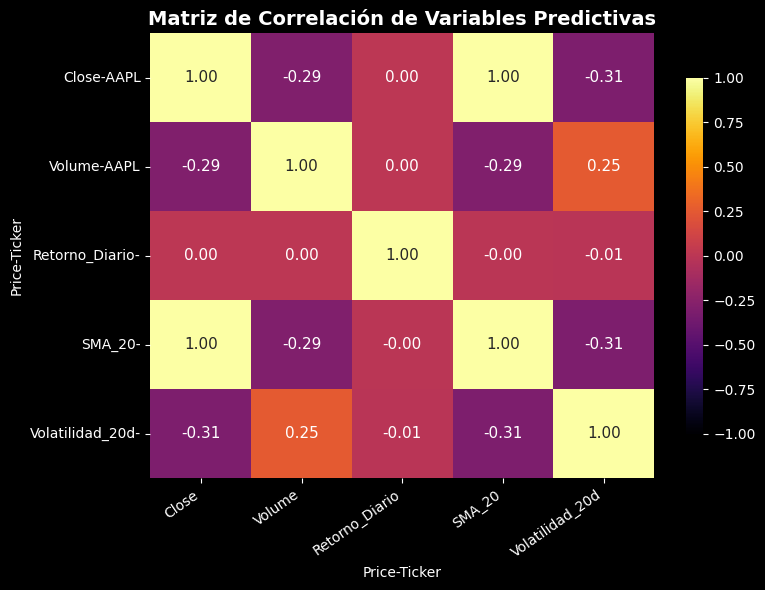

In [5]:
# --- Gráfica 4: Matriz de Correlación ---
variables_analisis = ['Close', 'Volume', 'Retorno_Diario', 'SMA_20', 'Volatilidad_20d']
matriz_corr = df[variables_analisis].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='inferno', fmt='.2f', vmin=-1, vmax=1,
            cbar_kws={'shrink': .8},
            annot_kws={"size": 11})
plt.xticks(ticks=[0.5, 1.5, 2.5, 3.5, 4.5],
           labels=['Close', 'Volume', 'Retorno_Diario', 'SMA_20', 'Volatilidad_20d'],
           rotation=35, ha='right')
plt.title('Matriz de Correlación de Variables Predictivas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()